In [1]:
!pip install rioxarray geopandas cartopy pymannkendall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.3 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [2]:
import xarray as xr
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pymannkendall as mk
import numpy as np
from scipy.stats import linregress

Resolution Check

In [4]:
gw_raw = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Groundwater/PENINSULAR_INDIA_GLDAS_GWS_cm_Monthly_2003_2024.nc")
print(gw_raw)

lat = gw_raw["lat"].values
lon = gw_raw["lon"].values

lat_res = abs(lat[1] - lat[0])
lon_res = abs(lon[1] - lon[0])


print("Lat resolution ~", lat_res, "degrees")
print("Lon resolution ~", lon_res, "degrees at equator")

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 263, lat: 67, lon: 75)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2003-02-01 2003-03-01 ... 2024-12-01
  * lat          (lat) float32 268B 8.125 8.375 8.625 ... 24.12 24.38 24.62
  * lon          (lon) float32 300B 72.62 72.88 73.12 ... 90.62 90.88 91.12
Data variables:
    spatial_ref  int64 8B ...
    GWS_tavg     (time, lat, lon) float32 5MB ...
Lat resolution ~ 0.25 degrees
Lon resolution ~ 0.25 degrees at equator


Monthly Mean Analysis

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


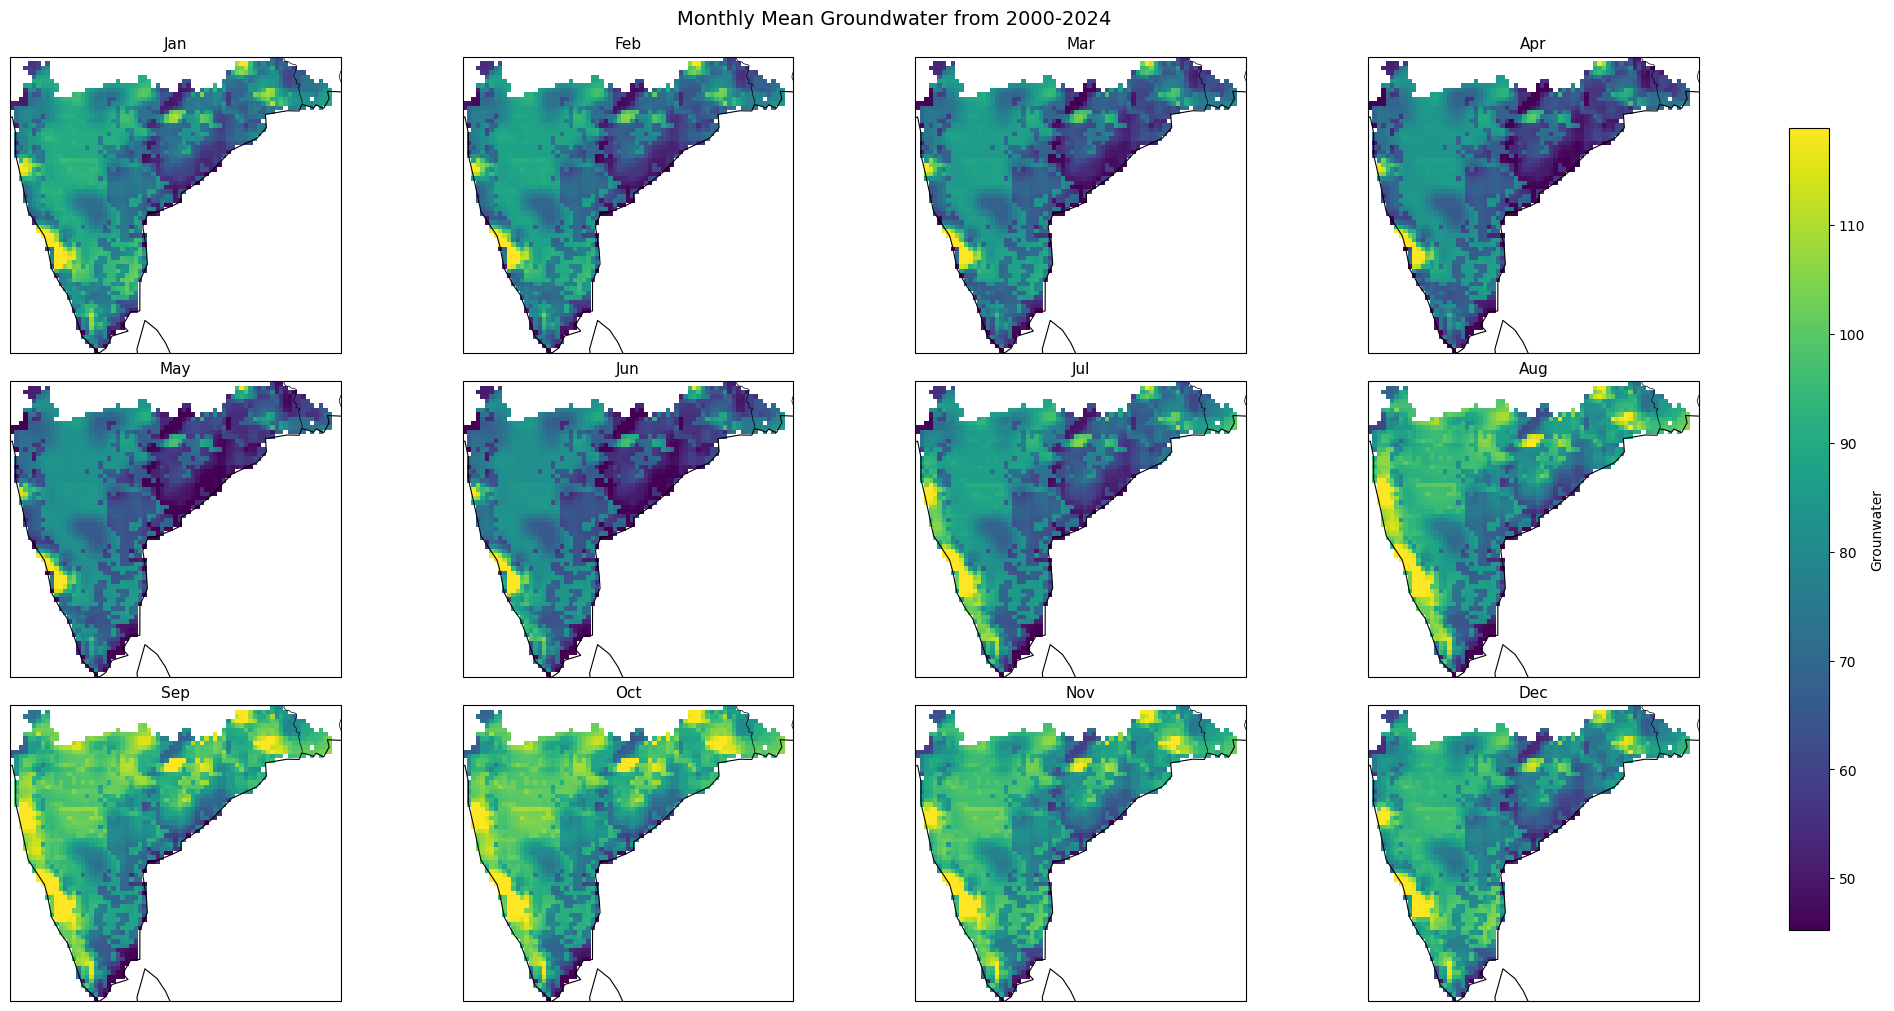

In [5]:
ds = xr.open_dataset("/content/drive/MyDrive/GNR644 - Water Balance/Data/Groundwater/PENINSULAR_INDIA_GLDAS_GWS_cm_Monthly_2003_2024.nc")
gw = ds["GWS_tavg"]

monthly_mean = gw.groupby("time.month").mean(dim="time")

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3, ncols=4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

vmin = float(monthly_mean.quantile(0.02))
vmax = float(monthly_mean.quantile(0.98))

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for i, ax in enumerate(axes.flat):
    data = monthly_mean.sel(month=i+1)

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(months[i], fontsize=11)

cbar = fig.colorbar(im, ax=axes, orientation="vertical", shrink=0.85)
cbar.set_label("Grounwater")

plt.suptitle(
    "Monthly Mean Groundwater from 2000-2024",
    fontsize=14
)

plt.show()

Monthly Mann Kendall Trend Analysis

In [14]:
# -------------------------------
# Load groundwater data
# -------------------------------
rain = ds["GWS_tavg"]

# -------------------------------
# Function: MK test for 1D series
# -------------------------------
def mann_kendall_1d(ts):
    ts = ts[~np.isnan(ts)]
    if len(ts) < 10:
        return np.nan, np.nan, np.nan, np.nan

    result = mk.original_test(ts)
    return result.trend, result.z, result.p, result.slope

# -------------------------------
# Loop over months
# -------------------------------
rain_results = {}

for month in range(1, 13):

    # Select monthly rainfall
    rain_m = rain.sel(time=rain["time.month"] == month)

    trend, z, p, slope = xr.apply_ufunc(
        mann_kendall_1d,
        rain_m,
        input_core_dims=[["time"]],
        output_core_dims=[[], [], [], []],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[object, float, float, float]
    )

    rain_results[month] = xr.Dataset({
        "trend": trend,
        "z_value": z,
        "p_value": p,
        "sens_slope": slope
    })


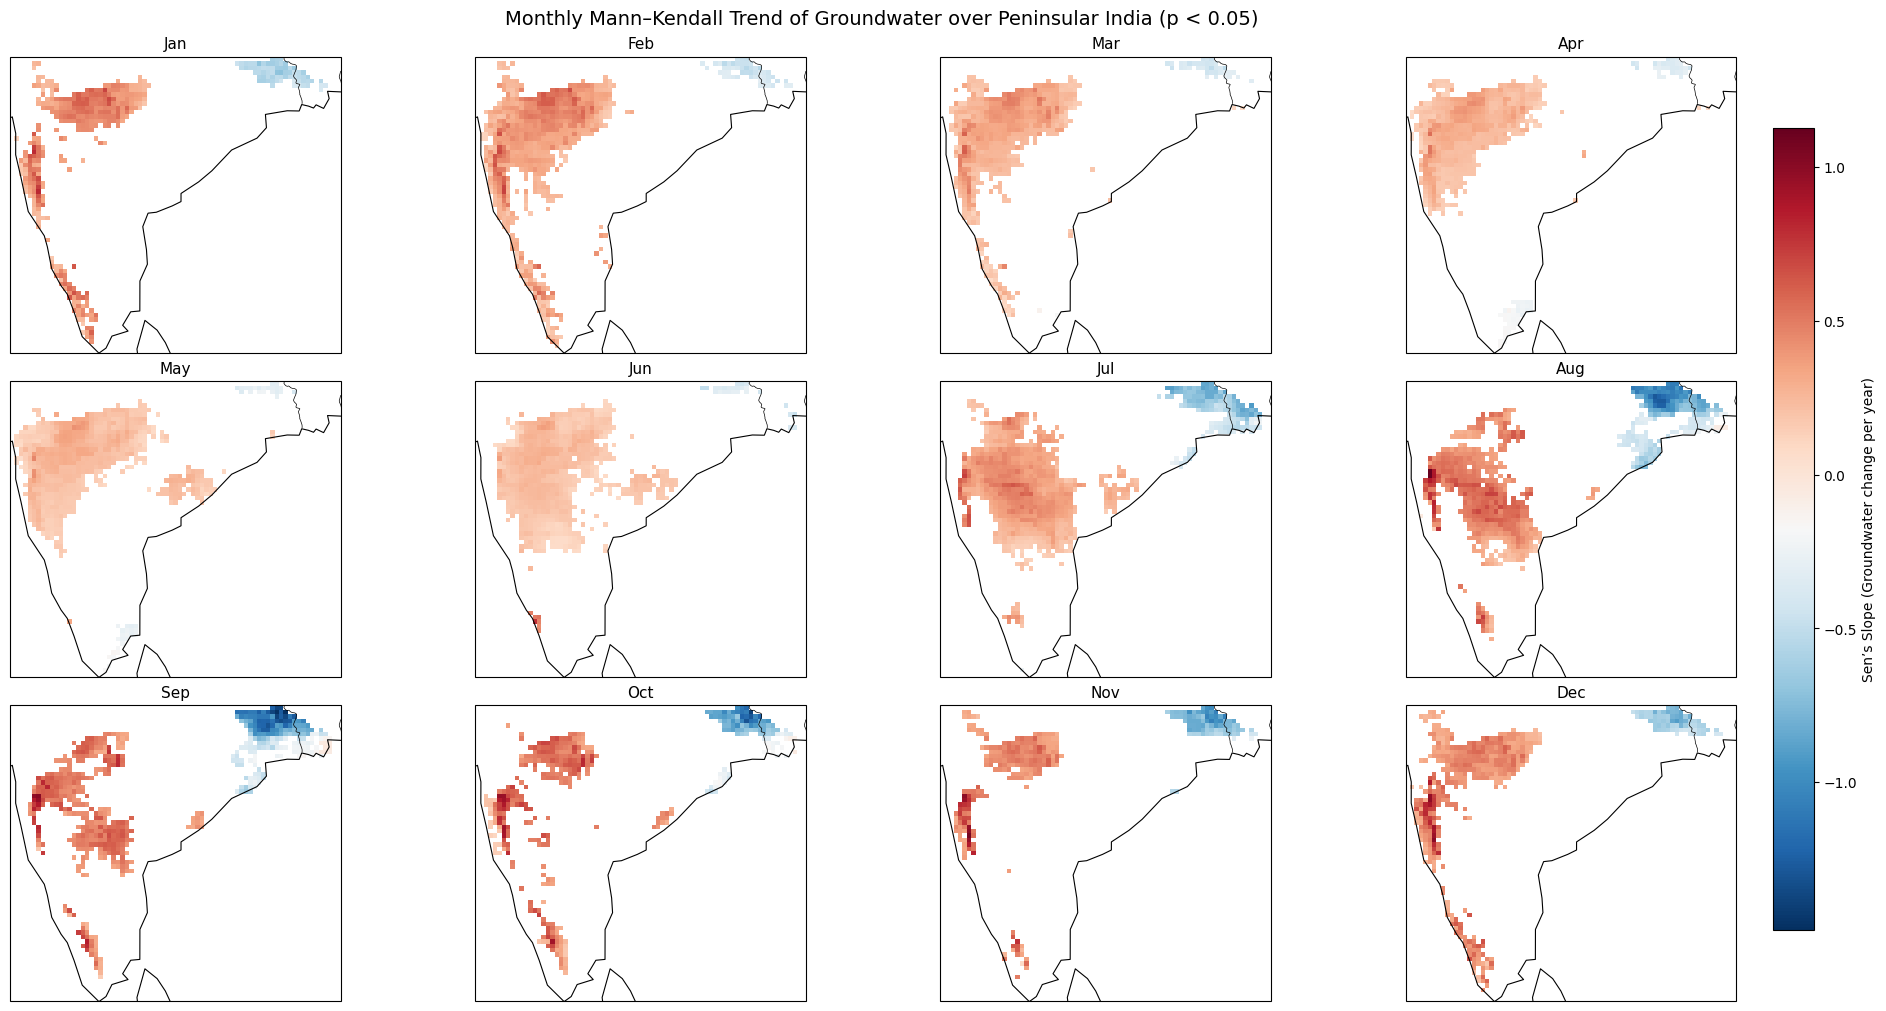

In [15]:
# ---------------------------------
# Month labels
# ---------------------------------
months = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

projection = ccrs.PlateCarree()

# ---------------------------------
# Find common color limits (significant rainfall slopes only)
# ---------------------------------
all_rain_slopes = []

for m in range(1, 13):
    rain_slope = rain_results[m]["sens_slope"]
    significant_slope = rain_slope.where(rain_results[m]["p_value"] < 0.05)
    all_rain_slopes.append(significant_slope)

vmin = np.nanmin([s.min().values for s in all_rain_slopes])
vmax = np.nanmax([s.max().values for s in all_rain_slopes])

# ---------------------------------
# Create 12-panel plot
# ---------------------------------
fig, axes = plt.subplots(
    3, 4,
    figsize=(20, 10),
    subplot_kw={"projection": projection},
    constrained_layout=True
)

for i, ax in enumerate(axes.flat):
    month = i + 1
    rainfall_mk = rain_results[month]

    significant_slope = rainfall_mk["sens_slope"].where(
        rainfall_mk["p_value"] < 0.05
    )

    im = significant_slope.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    ax.coastlines(resolution="110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Optional spatial focus
    # ax.set_extent([68, 98, 6, 38], crs=ccrs.PlateCarree())

    ax.set_title(months[i], fontsize=11)

# ---------------------------------
# Shared colorbar
# ---------------------------------
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="vertical",
    shrink=0.85,
    pad=0.02
)

cbar.set_label("Sen’s Slope (Groundwater change per year)")

plt.suptitle(
    "Monthly Mann–Kendall Trend of Groundwater over Peninsular India (p < 0.05)",
    fontsize=14
)

plt.show()


Time Series Graph of Mean

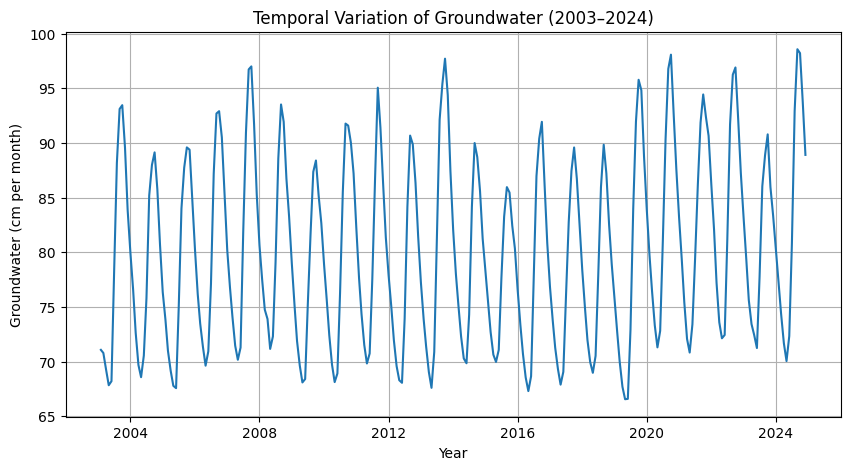

In [16]:
gldas_gw_ts = rain.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

gldas_gw_ts.plot(label='GLDAS (Groundwater)')

plt.title("Temporal Variation of Groundwater (2003–2024)")
plt.xlabel("Year")
plt.ylabel("Groundwater (cm per month)")
plt.grid(True)

plt.show()

Grouping of Mean by month

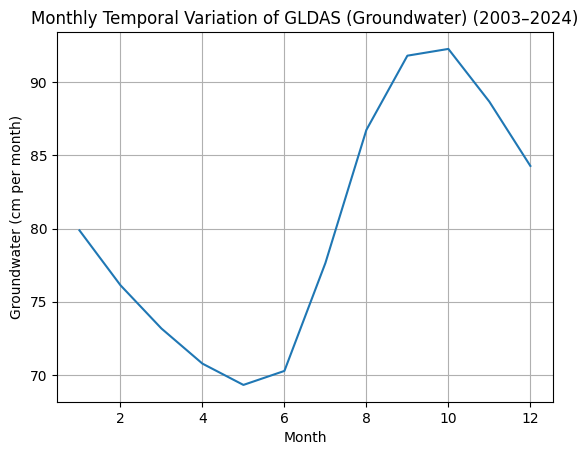

In [17]:
gldas_gw_season = gldas_gw_ts.groupby('time.month').mean()
gldas_gw_season.plot(label='GLDAS (Groundwater)')
plt.title("Monthly Temporal Variation of GLDAS (Groundwater) (2003–2024)")
plt.xlabel("Month")
plt.ylabel("Groundwater (cm per month)")
plt.grid(True)

Trend Analysis

In [18]:
time_gldas_gw = np.arange(len(gldas_gw_ts))

slope, intercept, r, p, std = linregress(time_gldas_gw, gldas_gw_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.013789798993456849
p-value: 0.048344194296359194


Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [19]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for GLDAS (Groundwater) from 2003 to 2024')

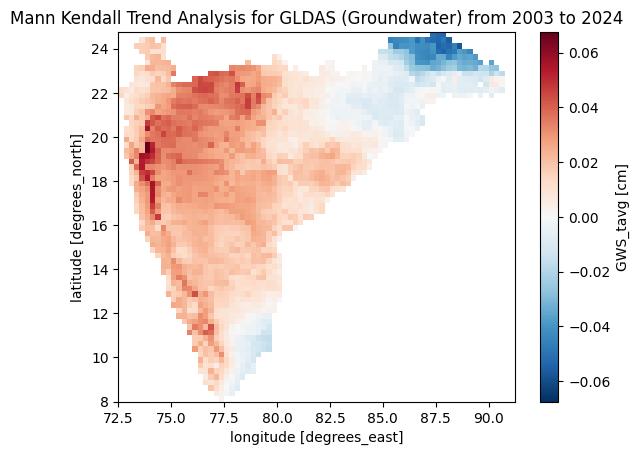

In [22]:
gw_trend = xr.apply_ufunc(
    trend_calc,
    rain,
    input_core_dims=[['time']],
    vectorize=True
)

gw_trend.plot()
plt.title("Mann Kendall Trend Analysis for GLDAS (Groundwater) from 2003 to 2024")

Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for GLDAS (Groundwater)')

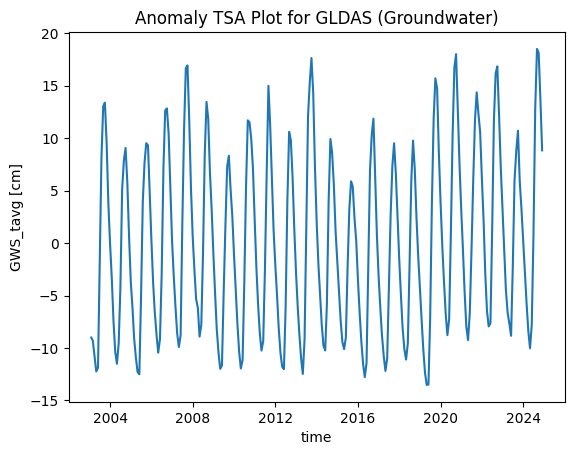

In [23]:
gldas_gw_mean = gldas_gw_ts.mean()
gldas_gw_anomaly = gldas_gw_ts - gldas_gw_mean

gldas_gw_anomaly.plot()
plt.title("Anomaly TSA Plot for GLDAS (Groundwater)")